# Late Attestations timings v2 - EDA

#### Maria Silva, August 2025

## 1. Imports

In [2]:
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
data_dir = os.path.join(repo_dir, "data")

# Add src to path
sys.path.append(os.path.join(repo_dir, "src"))

In [4]:
from late_atts_model_runner import load_data

In [5]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

## 2. Load data

In [6]:
df = load_data(data_dir, "sample_12243620_12294020")
df = df[df["header_from"]!="self_build"]
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 5263471 entries, 1060 to 10564738
Data columns (total 20 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   slot                          5263471 non-null  int64         
 1   atts_validator                5263471 non-null  int64         
 2   atts_subnet                   5263471 non-null  object        
 3   atts_arrival_time_ms          5263471 non-null  int64         
 4   request_datetime              4688856 non-null  datetime64[ns]
 5   publish_datetime              4688856 non-null  datetime64[ns]
 6   header_from                   5263471 non-null  object        
 7   publish_time_ms               5263471 non-null  float64       
 8   slot_start_datetime           5263471 non-null  datetime64[ns]
 9   request_time_ms               4688856 non-null  float64       
 10  p95_block_arrival_ms          5263471 non-null  int64         
 11 

## 3. EDA

In [6]:
late_df = df.copy()
late_df["is_late"] = late_df["net_atts_arrival_time_ms"] > 4500

sum(late_df["is_late"])/len(late_df)

0.01119546398184772

header_from
flashbots    -0.088088
titan        -0.201605
ultrasound   -0.045212
Name: p66_block_arrival_ms, dtype: float64


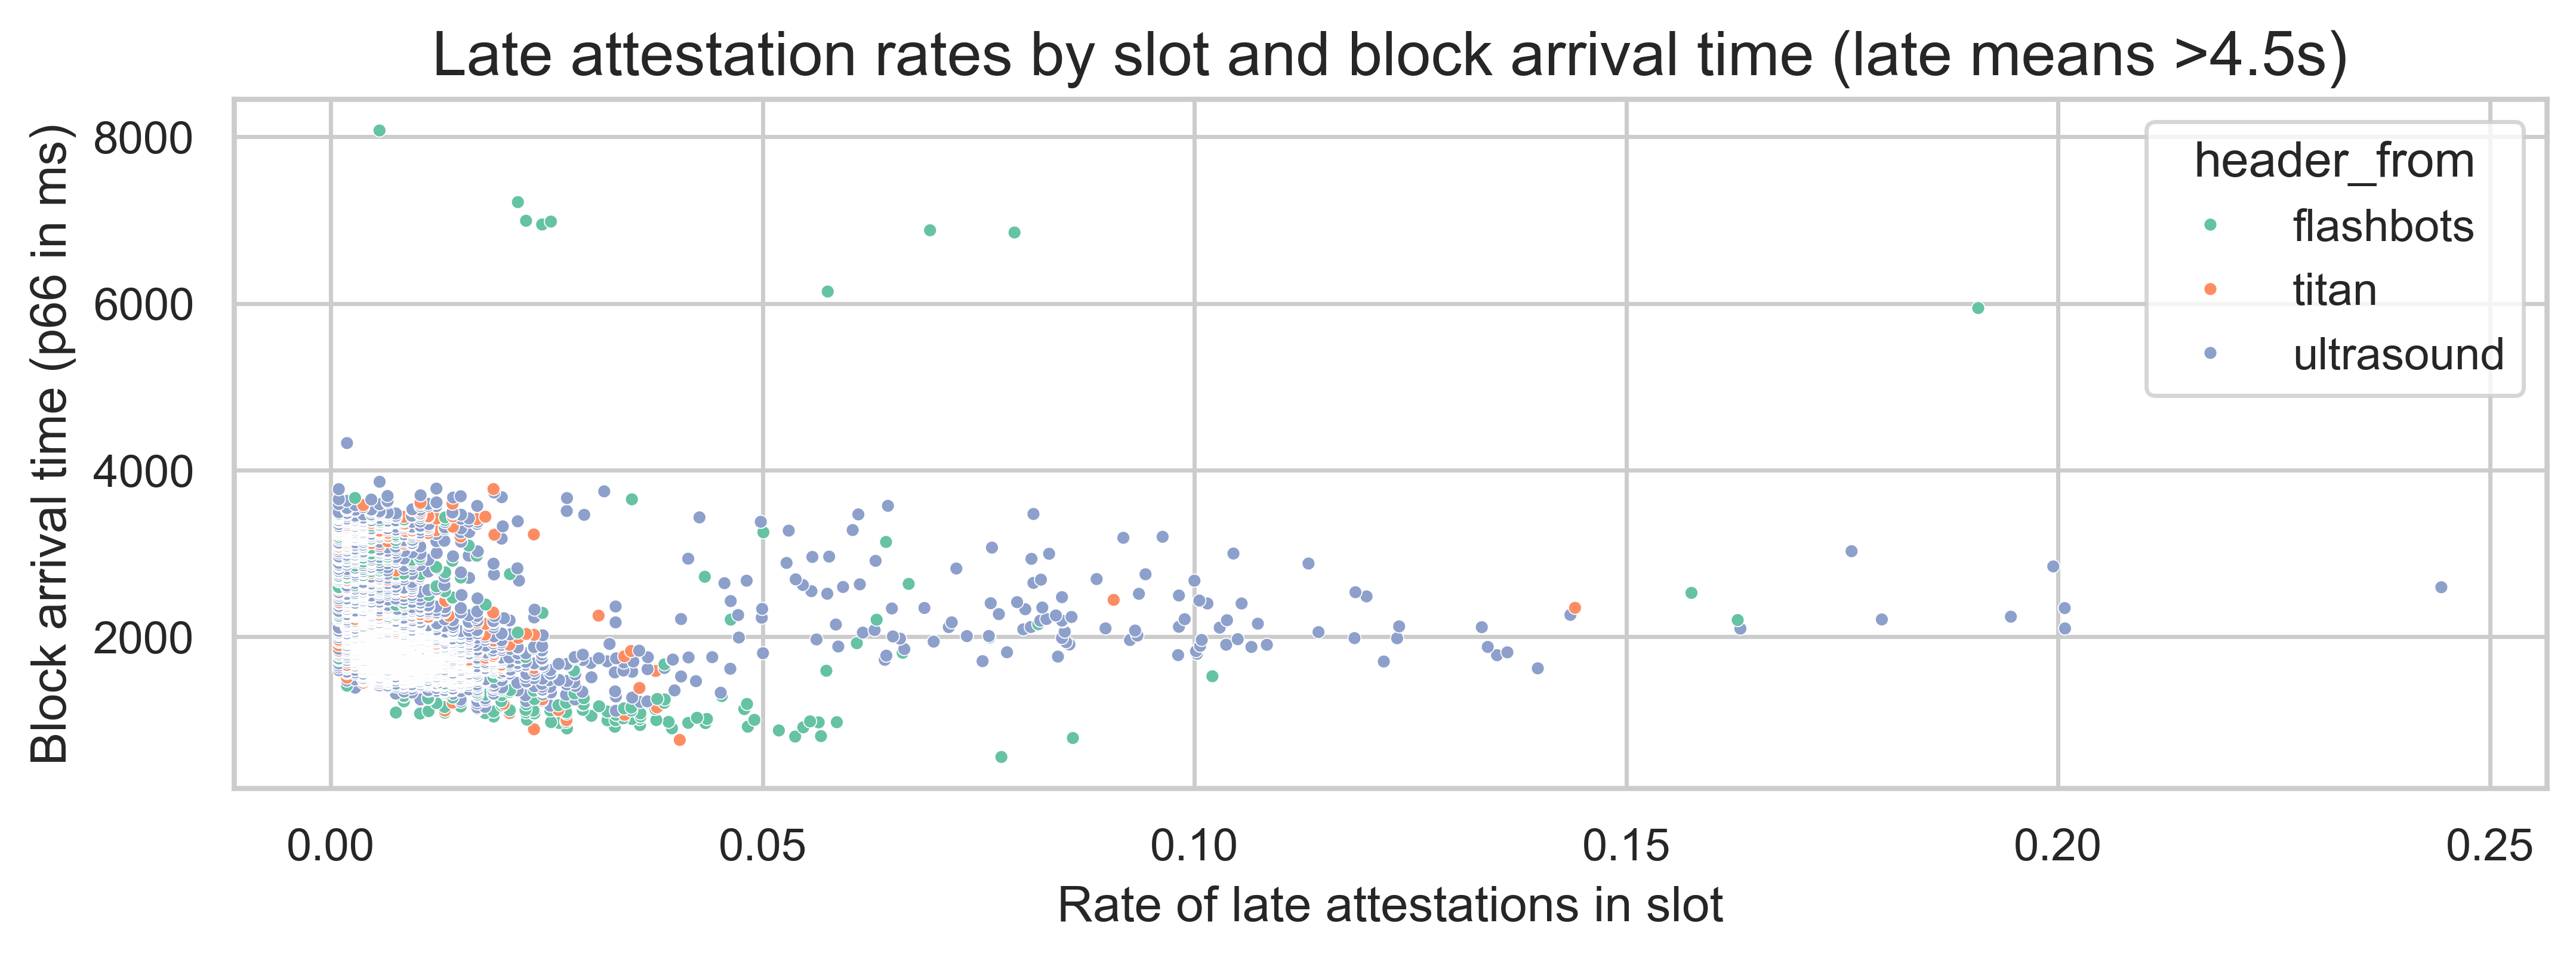

In [7]:
temp_df = df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "slot","p66_block_arrival_ms", "header_from"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index=["slot","p66_block_arrival_ms", "header_from"], values=0)
    .reset_index()
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])

print(temp_df.groupby("header_from")[["late_rate", "p66_block_arrival_ms"]].corr().iloc[0::2,-1].droplevel(1))

plt.figure(figsize=(10, 3))
sns.scatterplot(
    data=temp_df.sort_values("p66_block_arrival_ms"),
    x="late_rate",
    y="p66_block_arrival_ms",
    hue="header_from",
    s=10
)
plt.title("Late attestation rates by slot and block arrival time (late means >4.5s)")
plt.xlabel("Rate of late attestations in slot")
plt.ylabel("Block arrival time (p66 in ms)")

plt.show()

header_from
flashbots    -0.122684
titan         0.061990
ultrasound    0.068879
Name: block_gas_used, dtype: float64


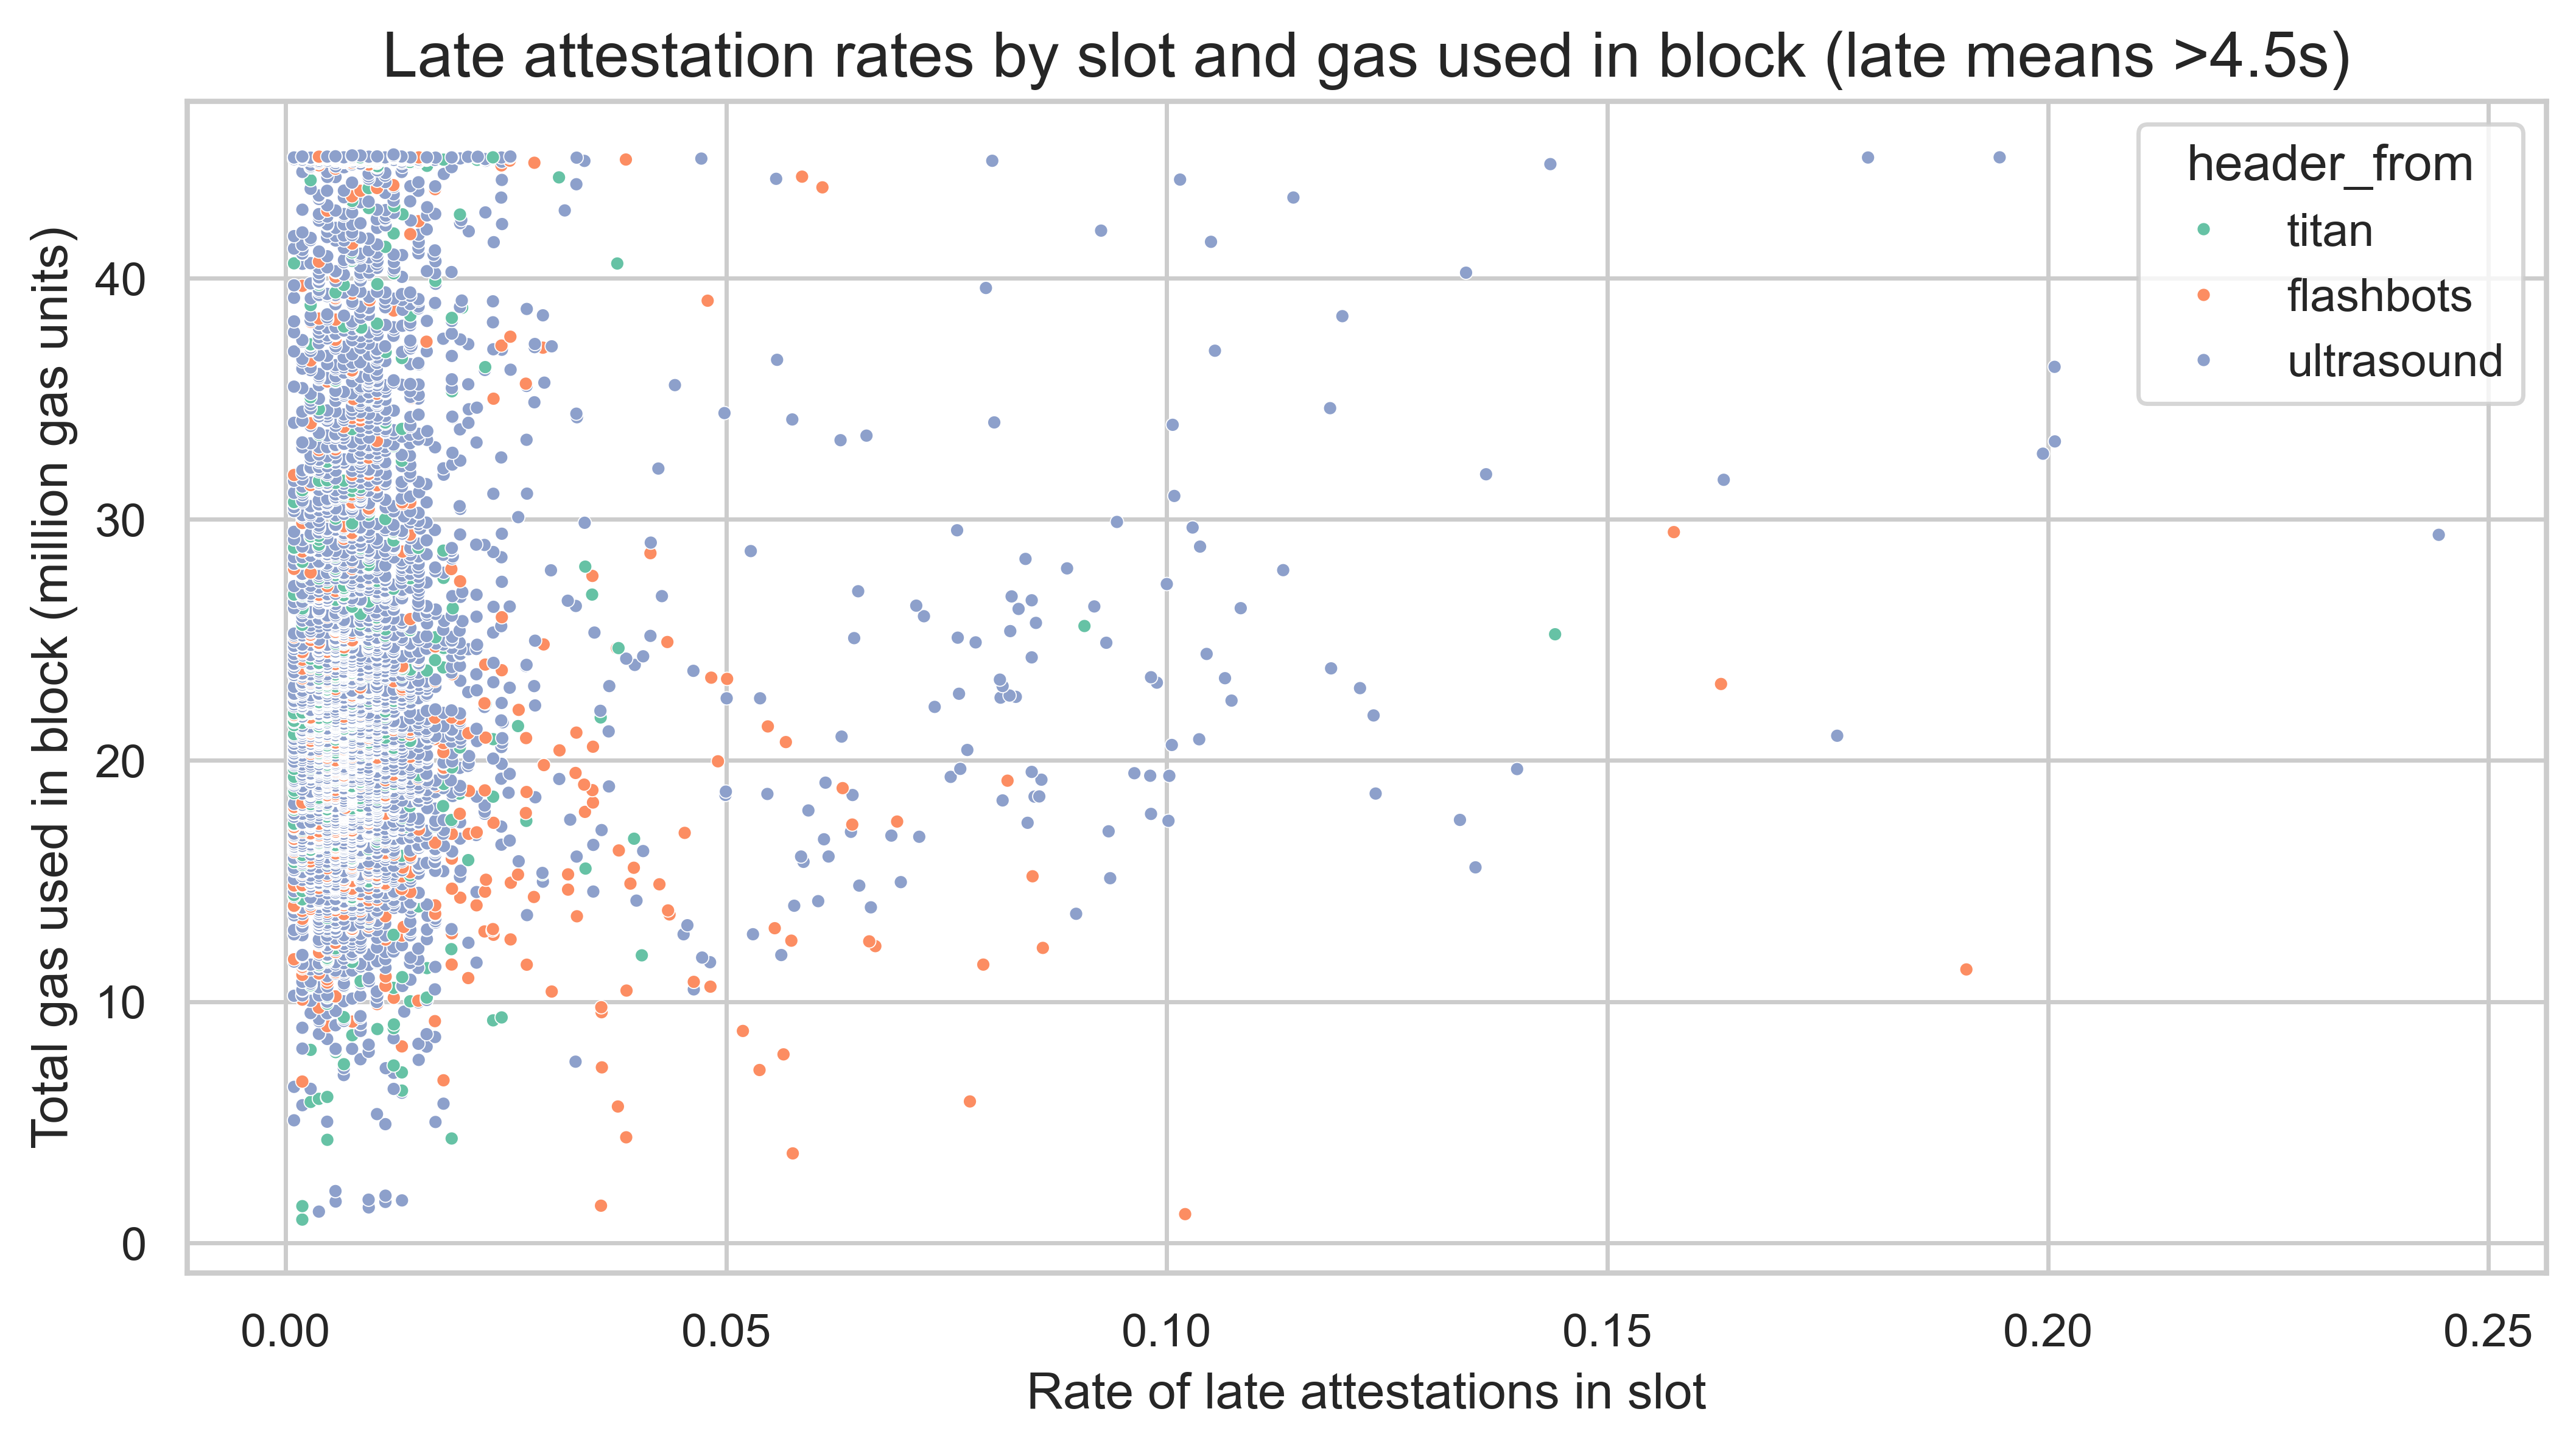

In [8]:
temp_df = df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "slot", "block_gas_used", "header_from"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index=["slot","block_gas_used", "header_from"], values=0)
    .reset_index()
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])
temp_df["block_gas_used"] = temp_df["block_gas_used"]/1000000

print(temp_df.groupby("header_from")[["late_rate", "block_gas_used"]].corr().iloc[0::2,-1].droplevel(1))

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=temp_df.sort_values("block_gas_used"),
    x="late_rate",
    y="block_gas_used",
    hue="header_from",
    s=10
)
plt.title("Late attestation rates by slot and gas used in block (late means >4.5s)")
plt.xlabel("Rate of late attestations in slot")
plt.ylabel("Total gas used in block (million gas units)")

plt.show()

header_from
flashbots    -0.149366
titan         0.098375
ultrasound    0.059791
Name: block_total_bytes_compressed, dtype: float64


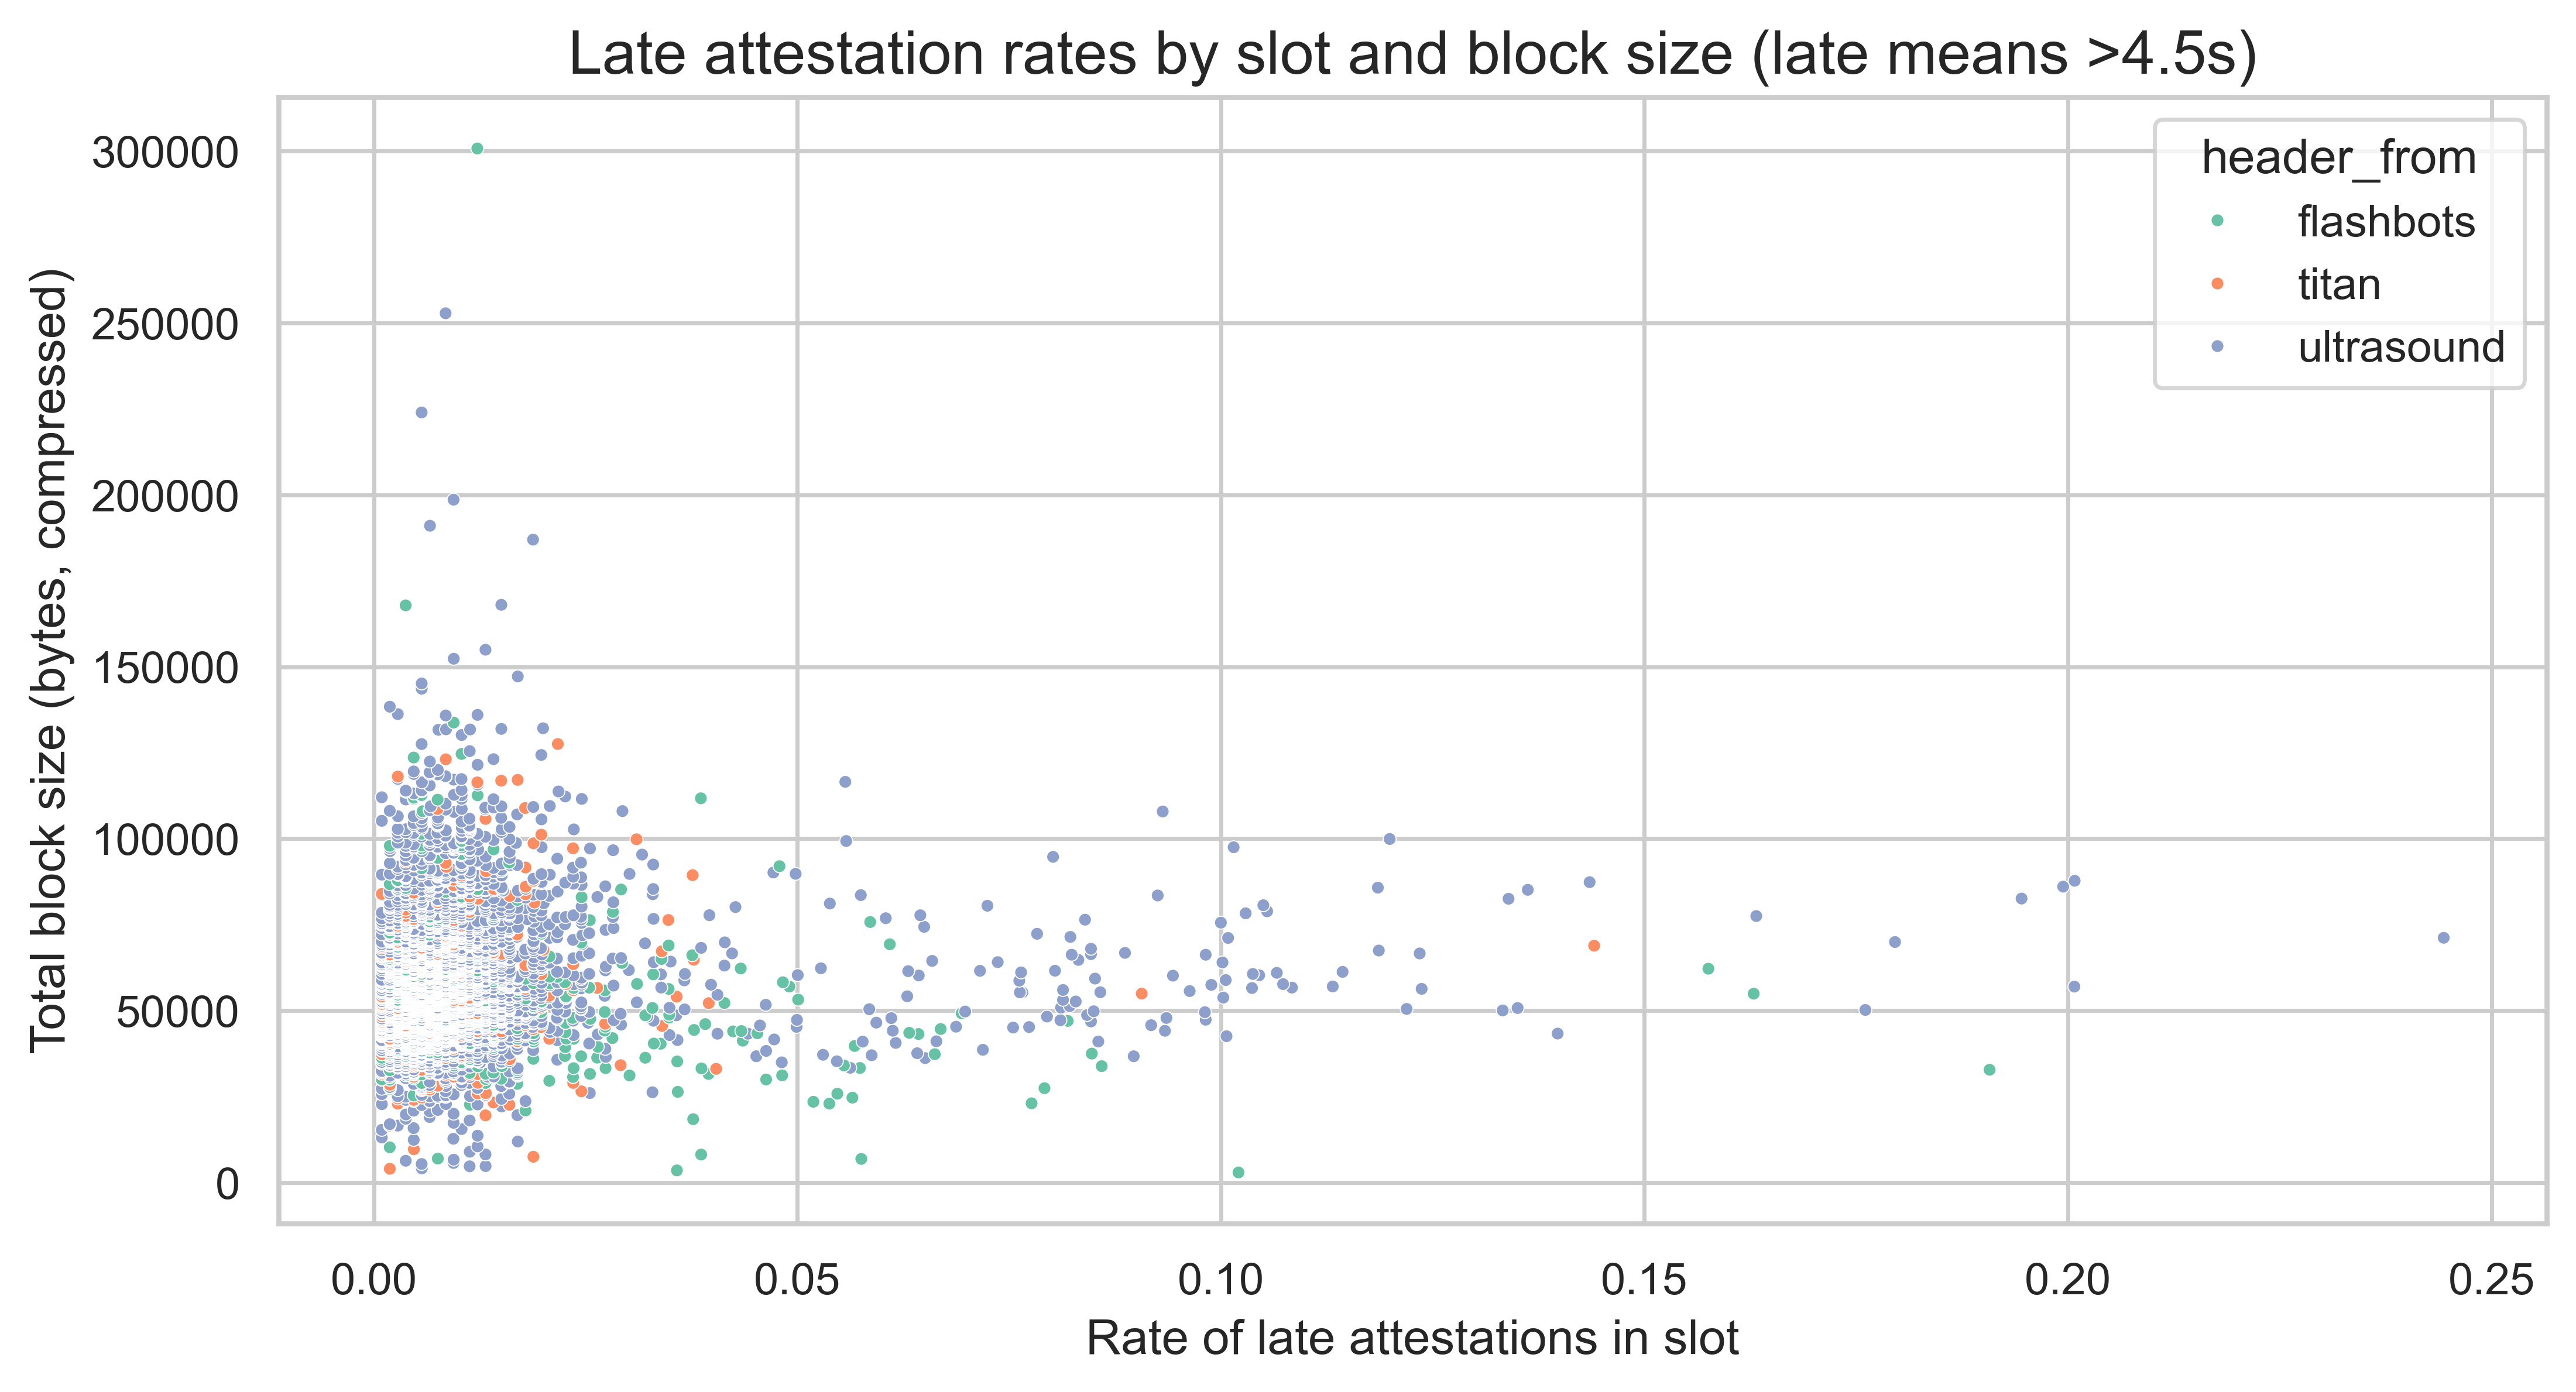

In [9]:
temp_df = df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "slot","block_total_bytes_compressed", "header_from"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index=["slot","block_total_bytes_compressed", "header_from"], values=0)
    .reset_index()
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])

print(temp_df.groupby("header_from")[["late_rate", "block_total_bytes_compressed"]].corr().iloc[0::2,-1].droplevel(1))

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=temp_df.sort_values("block_total_bytes_compressed"),
    x="late_rate",
    y="block_total_bytes_compressed",
    hue="header_from",
    s=10
)
plt.title("Late attestation rates by slot and block size (late means >4.5s)")
plt.xlabel("Rate of late attestations in slot")
plt.ylabel("Total block size (bytes, compressed)")

plt.show()

In [7]:
df.columns

Index(['slot', 'atts_validator', 'atts_subnet', 'atts_arrival_time_ms',
       'request_datetime', 'publish_datetime', 'header_from',
       'publish_time_ms', 'slot_start_datetime', 'request_time_ms',
       'p95_block_arrival_ms', 'p66_block_arrival_ms', 'avg_block_arrival_ms',
       'block_total_bytes_compressed', 'block_proposer_index',
       'block_gas_used', 'block_tx_count', 'block_blob_count', 'entity',
       'net_atts_arrival_time_ms'],
      dtype='object')

header_from
flashbots    -0.139559
titan         0.037747
ultrasound    0.043205
Name: block_tx_count, dtype: float64


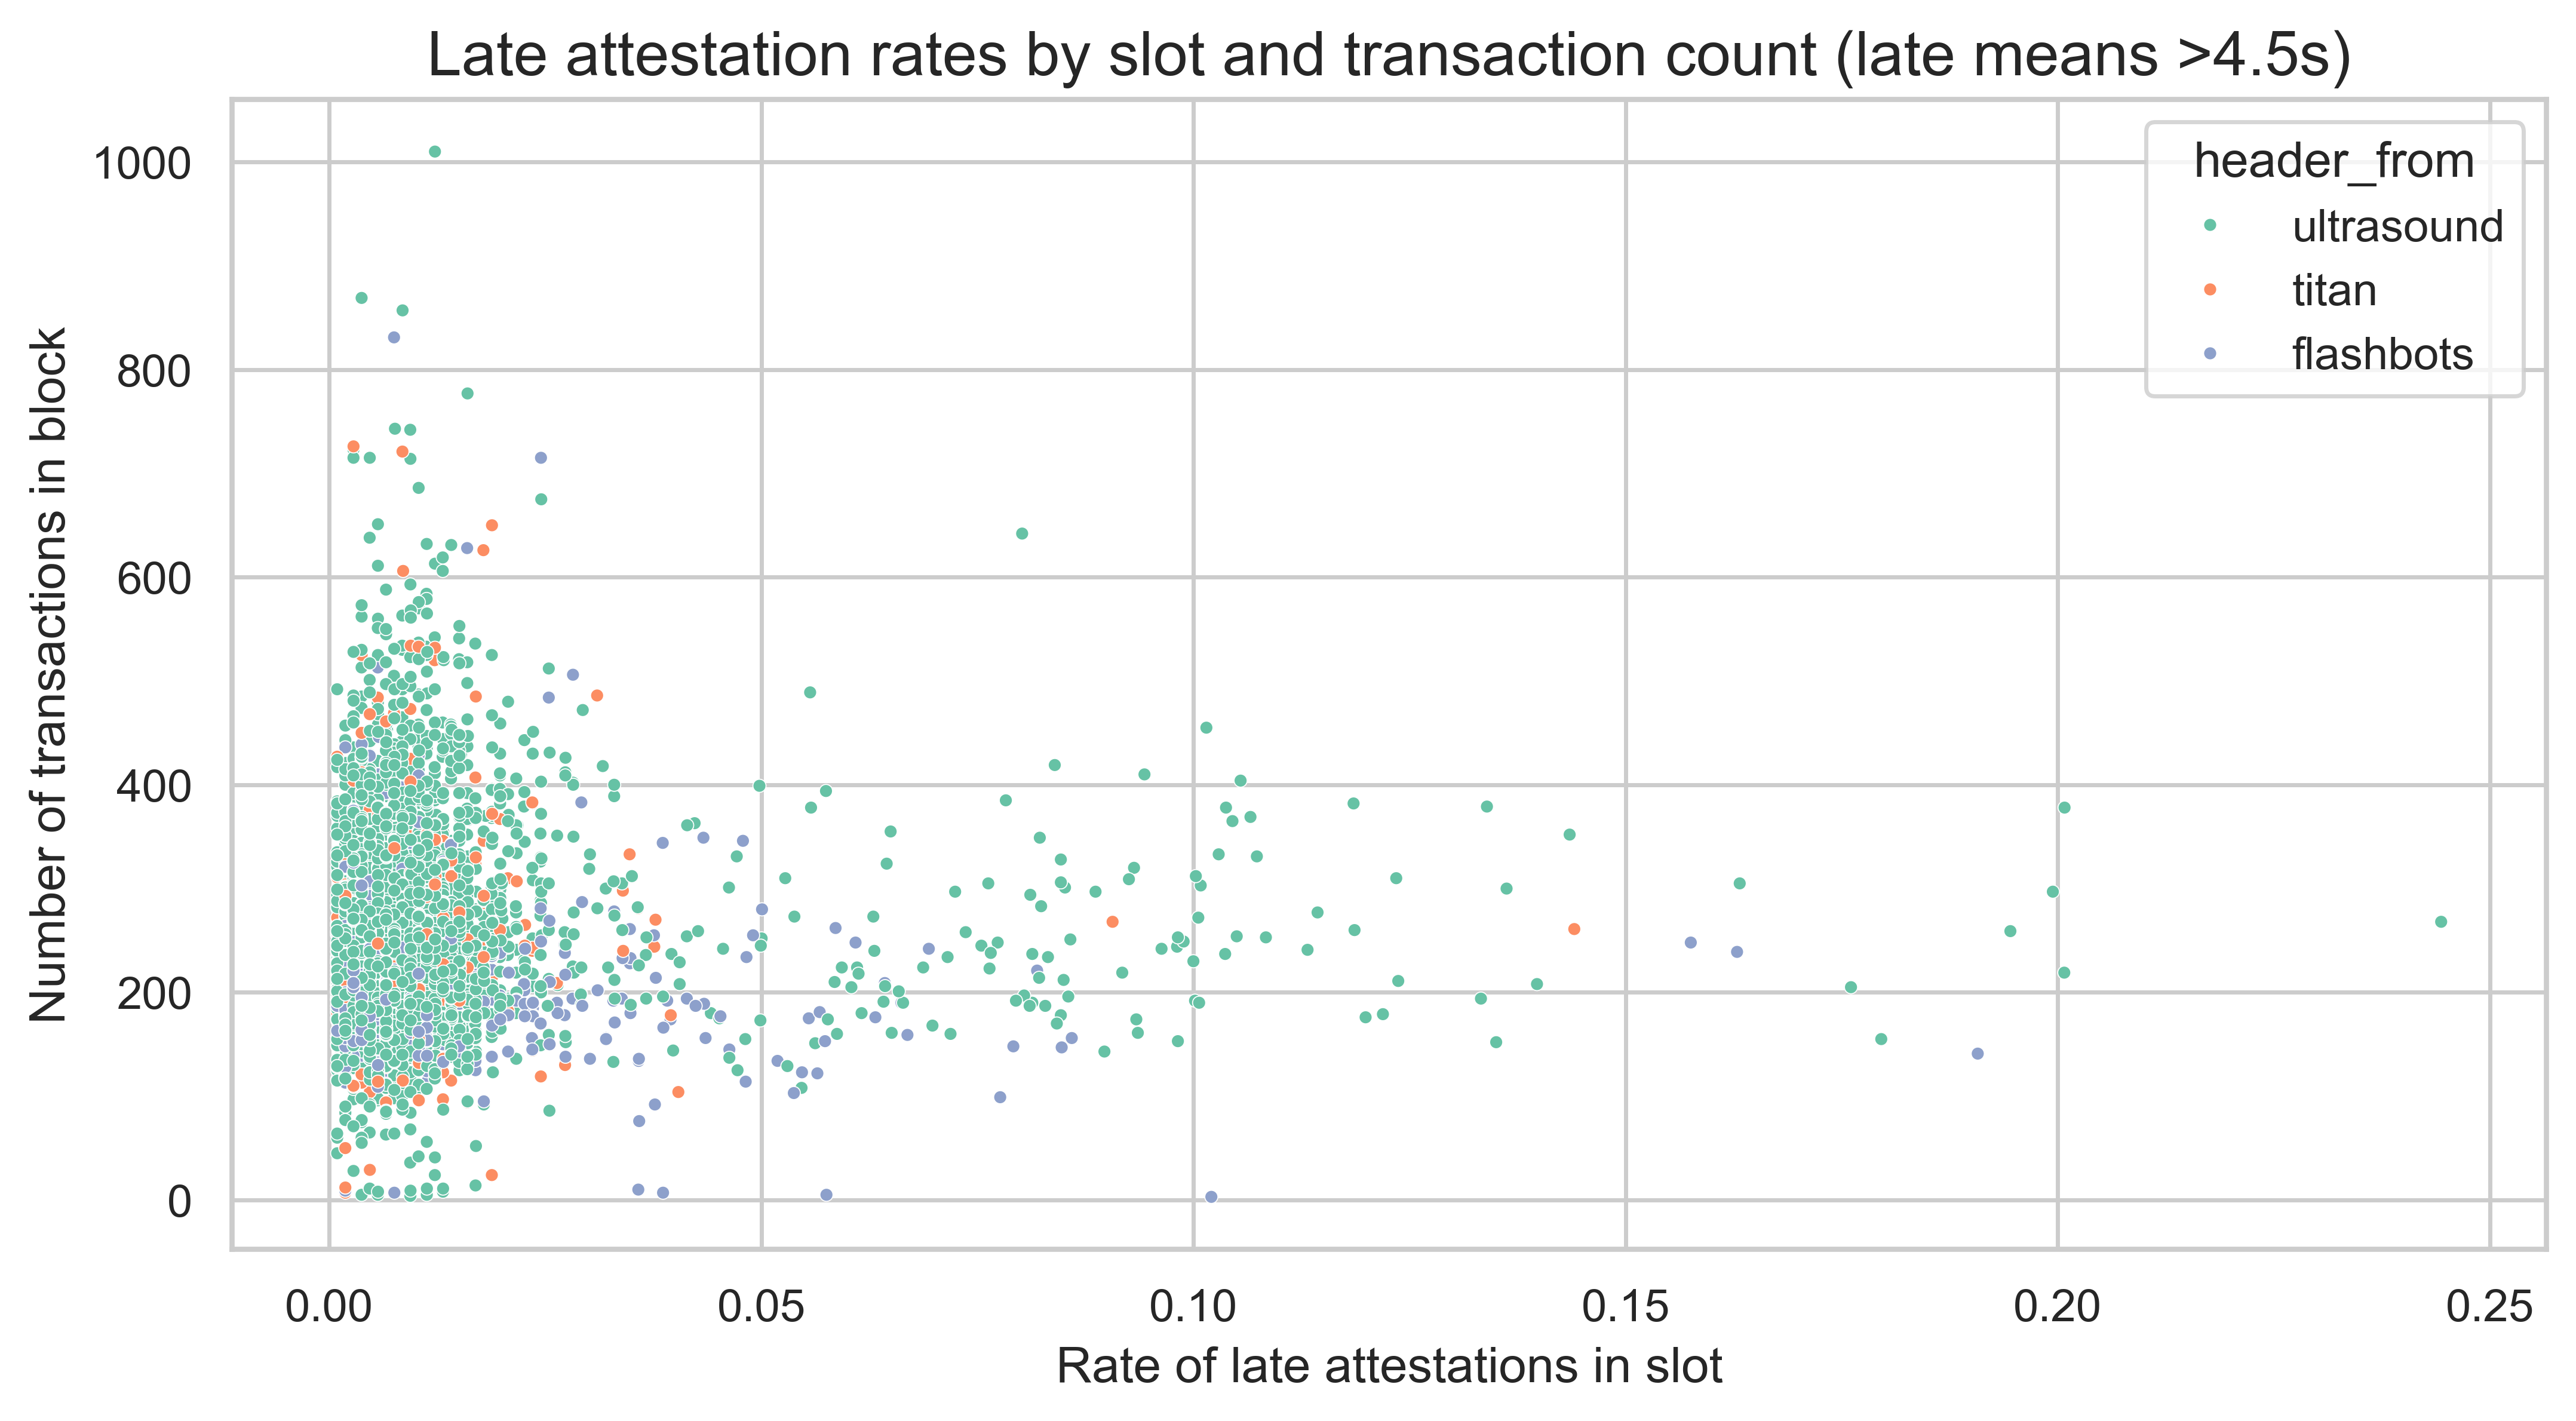

In [ ]:
temp_df = df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "slot","block_tx_count", "header_from"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index=["slot","block_tx_count", "header_from"], values=0)
    .reset_index()
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])

print(temp_df.groupby("header_from")[["late_rate", "block_tx_count"]].corr().iloc[0::2,-1].droplevel(1))

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=temp_df,
    x="late_rate",
    y="block_tx_count",
    hue="header_from",
    s=10
)
plt.title("Late attestation rates by slot and transaction count (late means >4.5s)")
plt.xlabel("Rate of late attestations in slot")
plt.ylabel("Number of transactions in block")

plt.show()

In [9]:
temp_df[["late_rate", "block_tx_count"]].corr()

is_late,late_rate,block_tx_count
is_late,,
late_rate,1.000000,0.014855
block_tx_count,0.014855,1.000000
